# DATASET

[https://www.kaggle.com/datasets/puneet6060/intel-image-classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

The Intel Image Dataset contains natural scene images divided into six categories:

- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

In this project, one image from the Buildings category is selected for image segmentation using the K-Means clustering algorithm.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# 1. Dataset Overview

The Intel Image Dataset contains six scene categories:

- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

One image from the Buildings category will be selected for segmentation.

In [4]:
import os

dataset_path = os.path.join("..", "Intel Image Dataset")

print("Dataset path:", dataset_path)
print(os.listdir(dataset_path))

Dataset path: ..\Intel Image Dataset
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Select an Image

In [5]:
folder = os.path.join(dataset_path, "buildings")

image_name = os.listdir(folder)[0]

image_path = os.path.join(folder, image_name)

print(image_name)

20057.jpg


## Load the Original Image

(150, 150, 3)


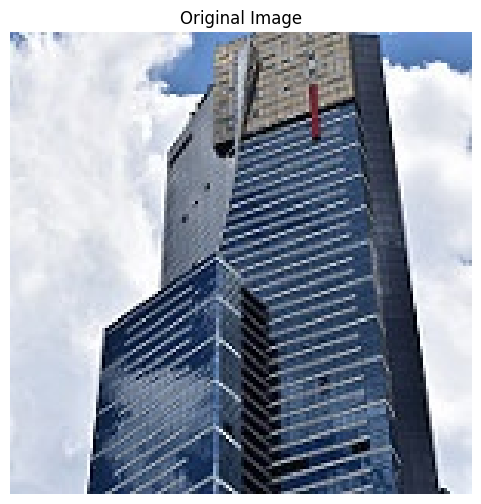

In [6]:
image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(image.shape)

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title("Original Image")

plt.axis("off")

plt.show()

# 2. Image Preprocessing

Resize the image before clustering.

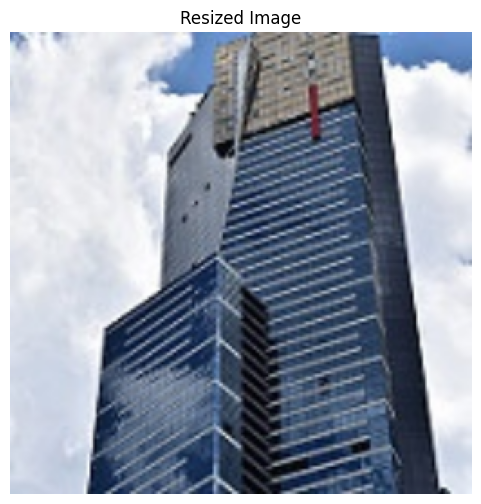

In [8]:
image = cv2.resize(image,(256,256))

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title("Resized Image")

plt.axis("off")

plt.show()

## Convert Image into Pixel Features

In [9]:
pixel_values = image.reshape((-1,3))

pixel_values = np.float32(pixel_values)

print(pixel_values.shape)

(65536, 3)


# 3. Apply K-Means Clustering

In [10]:
k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixel_values)

print("Finished Clustering")

Finished Clustering


## Cluster Centers

In [12]:
centers = np.uint8(kmeans.cluster_centers_)

print(centers)

[[225 229 237]
 [ 92 106 127]
 [ 53  67  91]
 [127 141 162]
 [ 25  34  53]]


## Generate Segmented Image

In [13]:
segmented_data = centers[labels]

segmented_image = segmented_data.reshape(image.shape)

# 4. Visualization

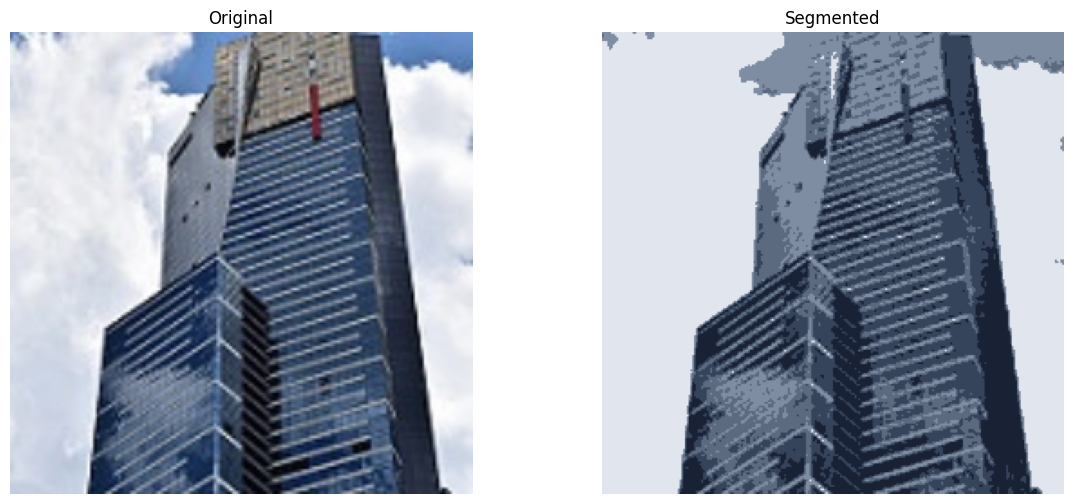

In [14]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.imshow(image)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(segmented_image)

plt.title("Segmented")

plt.axis("off")

plt.show()

## Compare Different Values of K

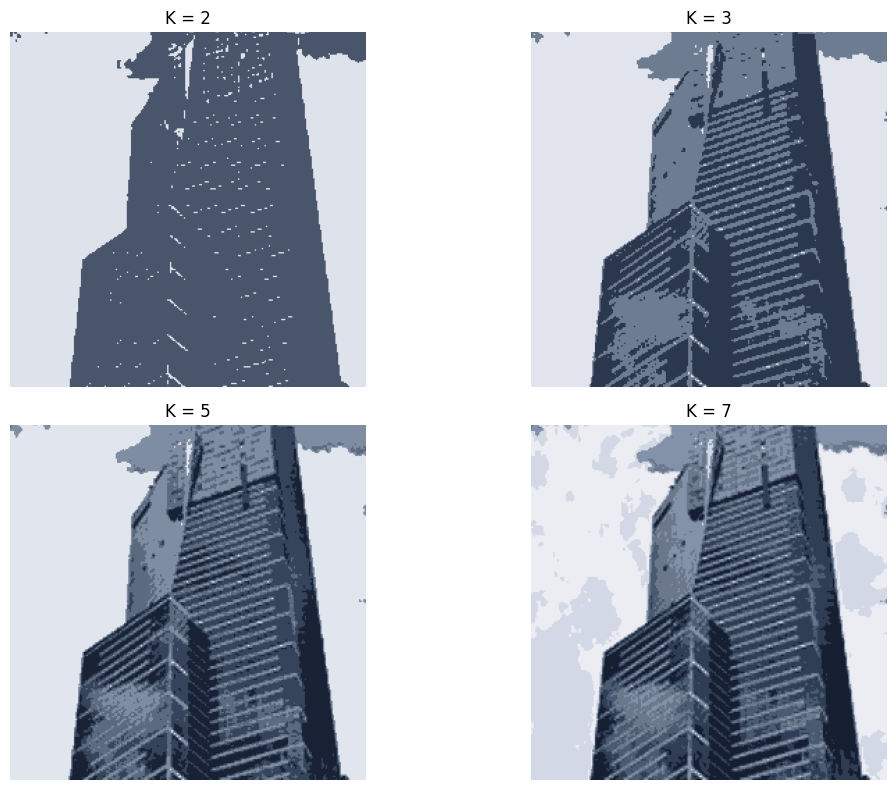

In [15]:
Ks = [2,3,5,7]

plt.figure(figsize=(12,8))

for i,k in enumerate(Ks):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(pixel_values)

    centers = np.uint8(model.cluster_centers_)

    segmented = centers[labels]

    segmented = segmented.reshape(image.shape)

    plt.subplot(2,2,i+1)

    plt.imshow(segmented)

    plt.title(f"K = {k}")

    plt.axis("off")

plt.tight_layout()

plt.show()

# 5. Save the Segmented Image

In [16]:
output = cv2.cvtColor(segmented_image,cv2.COLOR_RGB2BGR)

cv2.imwrite("segmented_image.jpg",output)

print("Image saved successfully.")

Image saved successfully.


# 6. Conclusion

The K-Means clustering algorithm successfully segmented the image based on RGB color similarity.

The experiment shows that different values of K produce different segmentation results.

K = 5 provides a good balance between image quality and computational efficiency.